In [28]:
import numpy as np
import pandas as pd
import gzip

In [29]:
weather_df = pd.read_csv("tsf_compare/data/weather/jena_climate_2009_2016.csv")
weather_df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [45]:
traffic_df = pd.read_csv("tsf_compare/data/traffic/traffic_with_date.csv", header=None)
traffic_df.shape

/tmp/ipykernel_8297/1039175908.py:1: DtypeWarning: Columns (862) have mixed types. Specify dtype option on import or set low_memory=False.
  traffic_df = pd.read_csv("tsf_compare/data/traffic/traffic_with_date.csv", header=None)


(17545, 863)

In [46]:
traffic_df.head()

,0,1,2,3,4,5,6,7,8,9,...,853,854,855,856,857,858,859,860,861,862
0,date,0.0000,1.0000,2.0000,3.0000,4.0000,5.0000,6.0000,7.0000,8.0000,...,852.0000,853.0000,854.0000,855.0000,856.0000,857.0000,858.0000,859.0000,860.0000,OT
1,2016-07-01 02:00:00,0.0048,0.0146,0.0289,0.0142,0.0064,0.0232,0.0162,0.0242,0.0341,...,0.0051,0.0051,0.0074,0.0079,0.0051,0.0051,0.0339,0.0051,0.0100,0.0121
2,2016-07-01 03:00:00,0.0072,0.0148,0.0350,0.0174,0.0084,0.0240,0.0201,0.0338,0.0434,...,0.0036,0.0036,0.0107,0.0058,0.0036,0.0036,0.0348,0.0036,0.0087,0.0136
3,2016-07-01 04:00:00,0.0040,0.0101,0.0267,0.0124,0.0049,0.0170,0.0127,0.0255,0.0332,...,0.0030,0.0030,0.0043,0.0050,0.0030,0.0030,0.0327,0.0030,0.0061,0.0107
4,2016-07-01 05:00:00,0.0039,0.0060,0.0218,0.0090,0.0029,0.0118,0.0088,0.0163,0.0211,...,0.0033,0.0033,0.0019,0.0052,0.0033,0.0033,0.0292,0.0033,0.0040,0.0071


In [47]:
import pandas as pd


def _prepare_dataframe(df):
    if "Date Time" not in df.columns:
        raise ValueError("DataFrame must contain a 'Date Time' column.")

    df = df.copy()

    # df["Date Time"] = pd.to_datetime(
    #     df["Date Time"],
    #     format="%d.%m.%Y %H:%M:%S",
    #     errors="raise"
    # )
    df["Date Time"] = pd.to_datetime(
            df["Date Time"],
            format="%Y-%m-%d %H:%M:%S",
            errors="raise"
        )

    df = df.sort_values("Date Time")
    df.set_index("Date Time", inplace=True)

    return df


def _get_resolution(df):
    """
    Estimate the sampling interval using the median difference.
    Returns a pandas Timedelta.
    """
    diffs = df.index.to_series().diff().dropna()

    if diffs.empty:
        raise ValueError("DataFrame must contain at least two timestamps.")

    return diffs.median()


def group_by_hour(df):
    """
    Group data by hour only if the original frequency is finer than 1 hour.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    if resolution >= pd.Timedelta(hours=1):
        raise ValueError(
            f"Cannot group by hour. Data resolution is {resolution}."
        )

    return df.resample("1h").mean(numeric_only=True)


def group_by_day(df):
    """
    Group data by day only if the original frequency is finer than 1 day.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    if resolution >= pd.Timedelta(days=1):
        raise ValueError(
            f"Cannot group by day. Data resolution is {resolution}."
        )

    return df.resample("1D").mean(numeric_only=True)


def group_by_month(df):
    """
    Group data by month only if the original frequency is finer than 1 month.
    """
    df = _prepare_dataframe(df)
    resolution = _get_resolution(df)

    # Approximate month as 28 days (safe lower bound)
    if resolution >= pd.Timedelta(days=28):
        raise ValueError(
            f"Cannot group by month. Data resolution is {resolution}."
        )

    return df.resample("MS").mean(numeric_only=True)

In [ ]:
# 15-minute data
hourly = group_by_hour(traffic_df)
hourly.head()

ValueError: time data "01.01.2009 00:10:00" doesn't match format "%y.%m.%d %H:%M:%S", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [ ]:
daily = group_by_day(weather_df)
daily.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01,999.145594,-6.810629,266.414545,-8.015594,91.086014,3.691119,3.355524,0.335315,2.091049,3.357832,1305.178252,0.778601,1.378252,181.863077
2009-01-02,999.600625,-3.728194,269.463194,-4.824861,92.086806,4.640069,4.267292,0.373056,2.659792,4.268750,1290.353194,1.419514,2.227361,125.072014
2009-01-03,998.548611,-5.271736,268.002292,-9.015833,76.458056,4.184792,3.107708,1.077014,1.937778,3.111944,1297.117014,1.250903,2.065069,190.383333
2009-01-04,988.510694,-1.375208,272.685347,-2.897014,89.417361,5.524306,4.938958,0.584861,3.114028,4.997014,1264.634514,1.720417,3.564861,213.069861
2009-01-05,990.405694,-4.867153,269.039306,-6.797292,86.260417,4.362708,3.806736,0.555625,2.397014,3.847778,1284.372778,3.800278,5.940000,118.287361


In [ ]:
monthly = group_by_month(weather_df)
monthly.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01,988.988075,-3.626617,270.409572,-5.887934,84.992651,5.000858,4.196778,0.804076,2.652147,4.256180,1276.954094,1.784855,2.892657,150.870558
2009-02-01,985.634010,0.169950,274.473770,-2.186749,84.723492,6.352691,5.353219,0.999516,3.388271,5.435491,1253.876491,2.045833,3.498914,193.228611
2009-03-01,986.123026,3.989944,278.266989,0.353797,78.468752,8.288454,6.389973,1.898461,4.044017,6.485105,1236.608163,2.429601,4.088239,201.683315
2009-04-01,987.523086,11.889757,286.080206,5.742546,69.176981,14.639894,9.316218,5.323556,5.892667,9.439019,1202.978444,1.853863,3.121630,143.162153
2009-05-01,992.105999,13.433905,287.247596,7.815836,70.967000,16.044648,10.835849,5.208658,6.826414,10.927278,1201.285078,2.080842,3.556891,168.264149


In [ ]:
import matplotlib.pyplot as plt

def plotting(x=None, y=None):
    plt.figure(figsize=(16, 6))
    if x is not None and y is not None:
        plt.plot(x, y)
    if x is None and y is not None:
        plt.plot(y)
    plt.grid()
    plt.show()

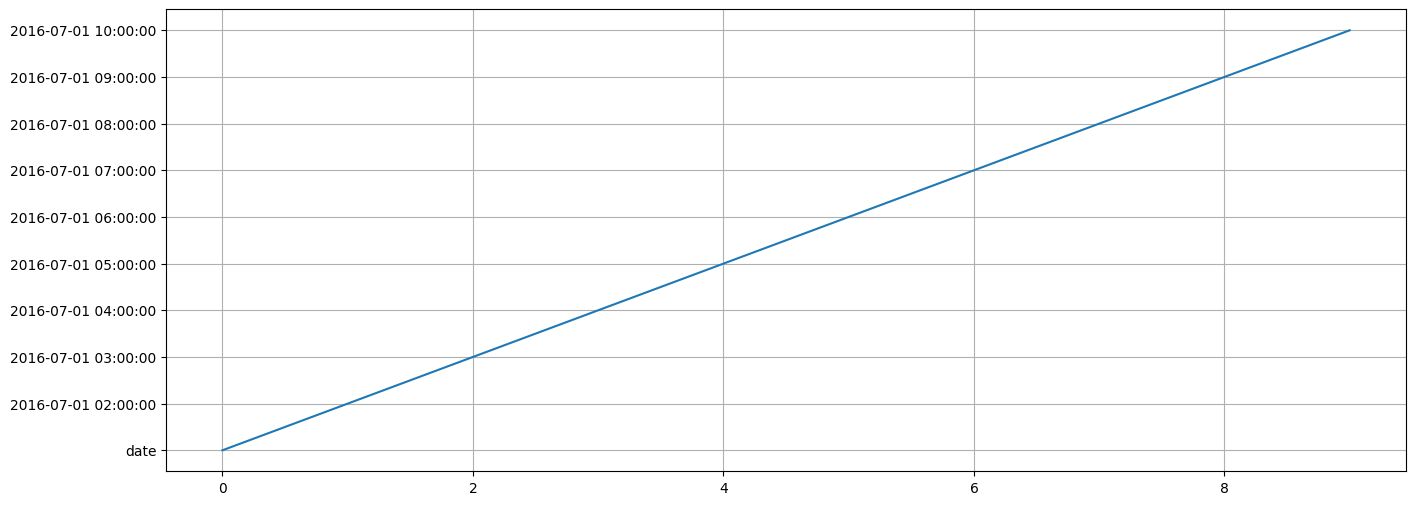

In [51]:
plotting(y=traffic_df[0][0:10])

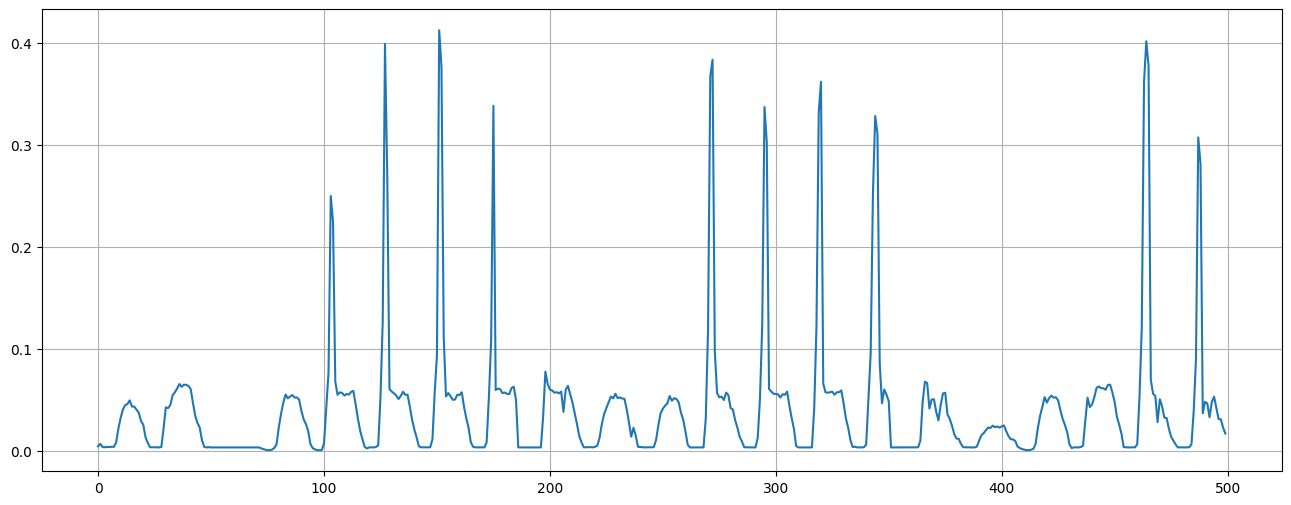

In [ ]:
plotting(y=traffic_df[0][:500])

In [ ]:
500//21

23

In [ ]:
ili_df.columns

Index(['date', '% WEIGHTED ILI', '%UNWEIGHTED ILI', 'AGE 0-4', 'AGE 5-24',
       'ILITOTAL', 'NUM. OF PROVIDERS', 'OT'],
      dtype='object')

In [38]:
# rename column name 'date' with 'Date Time' to use the group_by functions
ili_df.rename(columns={'date': 'Date Time'}, inplace=True)
ili_monthly = group_by_month(ili_df)
ili_monthly.head()

,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS,OT
Date Time,,,,,,,
2002-01-01,1.368428,1.213716,691.60,957.80,2401.80,828.40,197222.6
2002-02-01,1.523748,1.387565,843.50,1147.25,2999.50,923.25,216449.5
2002-03-01,1.951005,1.518038,881.75,1159.25,3069.75,909.50,209670.0
2002-04-01,2.341150,2.118866,1206.80,2235.00,4793.60,903.60,223958.2
2002-05-01,2.986133,2.874872,1551.00,3735.75,7066.25,880.00,245550.0


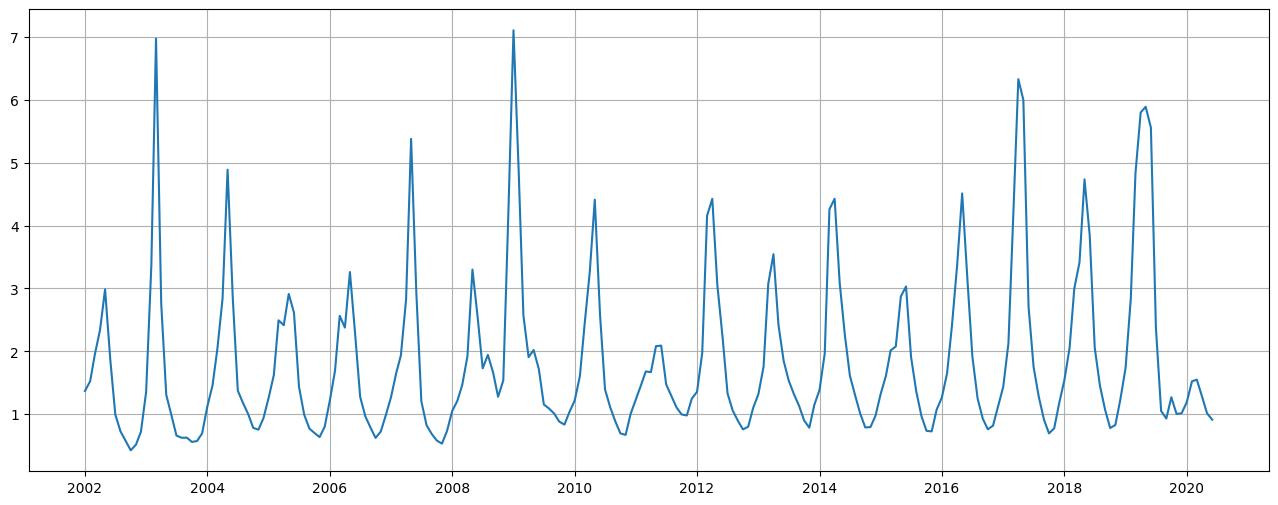

In [42]:
plotting(y=ili_monthly['% WEIGHTED ILI'])